## Imports

In [1]:
import pickle
import random
from typing import List, Tuple
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from maze import *

## Setup

In [2]:
def load_samples(pkl_path: str, n_samples: int = 2000, seed: int = 0):
    with open(pkl_path, 'rb') as f:
        all_data = pickle.load(f)
    random.Random(seed).shuffle(all_data)
    picked = all_data[:n_samples]
    mazes = []
    lengths = []

    for maze, length in picked:
        arr = np.array(maze, dtype=np.float32)

        H, W = arr.shape
        newH = H + 1
        newW = W + 1
        padded = np.zeros((newH, newW), dtype=np.float32)
        padded[:H, :W] = arr

        mazes.append(padded)
        lengths.append(float(length))

    return mazes, lengths


In [3]:
class MazeDataset(Dataset):
    def __init__(self, mazes: List[np.ndarray], lengths: List[float]):
        assert len(mazes) == len(lengths)
        self.mazes = mazes
        self.lengths = lengths
        self.n = len(mazes)
        # assume all mazes same shape
        self.h, self.w = mazes[0].shape


    def __len__(self):
        return self.n


    def __getitem__(self, idx):
        maze = self.mazes[idx]
        length = self.lengths[idx]
        # normalize length to float32 and scale roughly to [0,1]
        return torch.from_numpy(maze).unsqueeze(0), torch.tensor(length, dtype=torch.float32)

## Single-step transformer

In [4]:
class PatchEmbed(nn.Module):
    def __init__(self, in_ch, embed_dim, patch_size=(2,2)):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)


    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)
        B, E, Hp, Wp = x.shape
        x = x.flatten(2).transpose(1,2)
        return x, (Hp, Wp)

In [5]:
class SimpleTransformer(nn.Module):
    def __init__(self, embed_dim=256, depth=8, heads=8, mlp_dim=512, dropout=0.0):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleDict({
                'norm1': nn.LayerNorm(embed_dim),
                'attn': nn.MultiheadAttention(embed_dim, heads, dropout=dropout, batch_first=True),
                'norm2': nn.LayerNorm(embed_dim),
                'mlp': nn.Sequential(nn.Linear(embed_dim, mlp_dim), nn.GELU(), nn.Linear(mlp_dim, embed_dim))
            }))


    def forward(self, x):
        for l in self.layers:
            x = x + l['attn'](l['norm1'](x), l['norm1'](x), l['norm1'](x))[0]
            x = x + l['mlp'](l['norm2'](x))
        return x

In [6]:
class TLike(nn.Module):
    def __init__(self, img_size=(20,20), patch_size=(1,1), in_ch=1, embed_dim=256, depth=8, heads=8):
        super().__init__()
        self.patch_embed = PatchEmbed(in_ch, embed_dim, patch_size=patch_size)
        Hp = img_size[0] // patch_size[0]
        Wp = img_size[1] // patch_size[1]
        self.n_patches = Hp * Wp
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, embed_dim) * 0.02)
        self.length_proj = nn.Sequential(nn.Linear(1, embed_dim), nn.GELU(), nn.Linear(embed_dim, embed_dim))
        self.transformer = SimpleTransformer(embed_dim=embed_dim, depth=depth, heads=heads)
        self.to_pixels = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, patch_size[0]*patch_size[1]))
        self.patch_size = patch_size
        self.img_size = img_size


    def forward(self, x, lengths):
        B = x.shape[0]
        tokens, (Hp, Wp) = self.patch_embed(x)
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]
        # broadcast length embedding to tokens
        lengths = lengths.view(B,1,1)
        l_embed = self.length_proj(lengths)
        tokens = tokens + l_embed
        out = self.transformer(tokens)
        pixels = self.to_pixels(out)
        # reconstruct image
        p_h, p_w = self.patch_size
        pixels = pixels.reshape(B, Hp, Wp, p_h, p_w).permute(0,1,3,2,4).reshape(B, 1, Hp*p_h, Wp*p_w)
        return pixels # raw logits; apply sigmoid outside

In [7]:
def train_model(pkl_path='mazes.pkl', n_samples=2000, batch_size=32, epochs=5, device='mps'):
    mazes, lengths = load_samples(pkl_path, n_samples=n_samples)
    ds = MazeDataset(mazes, lengths)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)


    model = TLike(img_size=mazes[0].shape, patch_size=(2,2), embed_dim=256, depth=8, heads=8)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    loss_fn = nn.BCEWithLogitsLoss()
    train_losses = []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        epoch_losses = []

        for xb, lengths in dl:
            xb = xb.to(device) # (B,1,H,W)
            lengths = lengths.to(device).unsqueeze(1)
            tgt = xb
            opt.zero_grad()
            out = model(xb, lengths)
            out = out[:, :, :xb.shape[2], :xb.shape[3]] # crop if needed
            loss = loss_fn(out, tgt)
            loss.backward()
            opt.step()
            running += loss.item()
            epoch_losses.append(loss.item())
        mean_epoch_loss = sum(epoch_losses) / len(epoch_losses)
        train_losses.append(mean_epoch_loss)

        print(f"Epoch {epoch+1}: loss={mean_epoch_loss:.4f}")



    torch.save(model.state_dict(), 'transformer_maze.pt')
    return model

In [8]:
def generate_from_length(model, desired_len: float, device='cpu'):
    model.to(device)
    model.eval()
    with torch.no_grad():
        z = torch.zeros((1,1,model.img_size[0], model.img_size[1]), dtype=torch.float32).to(device)
        len_t = torch.tensor([float(desired_len)], dtype=torch.float32).to(device)
        out = model(z, len_t).squeeze(0).squeeze(0)
        probs = torch.sigmoid(out).cpu().numpy()
        maze = (probs > 0.5).astype(int)
        return maze

In [9]:
device = torch.device("mps")

model = train_model(pkl_path='mazes.pkl', n_samples=2000, batch_size=32, epochs=7, device='mps')

sample = generate_from_length(model, 67.0)
sample = sample[:, :19]      # remove last row
sample = sample[:19, :]      # remove last column

Epoch 1: loss=0.4592
Epoch 2: loss=0.4155
Epoch 3: loss=0.4347
Epoch 4: loss=0.3976
Epoch 5: loss=0.1140
Epoch 6: loss=0.0098
Epoch 7: loss=0.0076


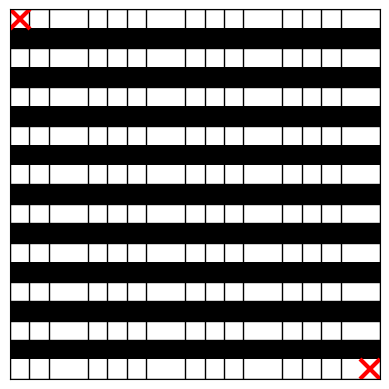

In [13]:
visualize_maze(sample, text=False)

## Conditional Variational Autoencoder

In [14]:
F = torch.nn.functional

class ConvEncoder(nn.Module):
    def __init__(self, latent_dim=64, in_size=(20,20)):
        super().__init__()
        # assume input H,W divisible by 4 (20x20 common). adjust if needed.
        self.conv1 = nn.Conv2d(1, 32, 4, 2, 1)   # H/2
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)  # H/4
        self.conv3 = nn.Conv2d(64, 128, 3, 1, 1)
        H, W = in_size
        feat_h = H // 4
        feat_w = W // 4
        self._flat = 128 * feat_h * feat_w
        self.fc_mu = nn.Linear(self._flat, latent_dim)
        self.fc_logvar = nn.Linear(self._flat, latent_dim)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.act(self.conv3(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class ConvDecoder(nn.Module):
    def __init__(self, latent_dim=64, len_emb_dim=16, out_size=(20,20)):
        super().__init__()
        H, W = out_size
        feat_h = H // 4
        feat_w = W // 4
        self.fc = nn.Linear(latent_dim + len_emb_dim, 128 * feat_h * feat_w)
        self.act = nn.GELU()
        self.deconv1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)  # *2
        self.deconv2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)   # *2
        self.outc = nn.Conv2d(32, 1, 3, 1, 1)
    def forward(self, zc, H, W):
        h = self.fc(zc)
        feat_h = H // 4
        feat_w = W // 4
        h = h.view(h.size(0), 128, feat_h, feat_w)
        h = self.act(h)
        h = self.act(self.deconv1(h))
        h = self.act(self.deconv2(h))
        logits = self.outc(h)
        return logits


In [15]:
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=64, len_emb_dim=16, in_size=(20,20)):
        super().__init__()
        self.enc = ConvEncoder(latent_dim=latent_dim, in_size=in_size)
        self.len_embed = nn.Sequential(nn.Linear(1, len_emb_dim), nn.GELU(), nn.Linear(len_emb_dim, len_emb_dim))
        self.dec = ConvDecoder(latent_dim=latent_dim, len_emb_dim=len_emb_dim, out_size=in_size)
        self.latent_dim = latent_dim
        self.in_size = in_size

    def reparam(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, length):
        mu, logvar = self.enc(x)
        z = self.reparam(mu, logvar)
        le = self.len_embed(length.unsqueeze(1))
        zc = torch.cat([z, le], dim=1)
        logits = self.dec(zc, *self.in_size)
        return logits, mu, logvar

    def generate(self, length, n=1, device='cpu'):
        self.to(device)
        self.eval()
        with torch.no_grad():
            z = torch.randn(n, self.latent_dim, device=device)
            le = torch.tensor([length]*n, dtype=torch.float32, device=device).unsqueeze(1)
            le = self.len_embed(le)
            zc = torch.cat([z, le], dim=1)
            logits = self.dec(zc, *self.in_size)
            probs = torch.sigmoid(logits)
            return (probs > 0.5).long().cpu().numpy().squeeze(1)


In [16]:
def kld_loss(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

def train_cvae(pkl_path='mazes.pkl', n_samples=2000, batch_size=64, epochs=20, lr=1e-3, latent_dim=64, device='mps'):
    mazes, lengths = load_samples(pkl_path, n_samples=n_samples)
    # infer input size from first sample
    H, W = mazes[0].shape
    ds = MazeDataset(mazes, lengths)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = ConditionalVAE(latent_dim=latent_dim, len_emb_dim=16, in_size=(H,W)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()
    beta = 1e-3

    recon_hist = []
    kld_hist = []
    for epoch in range(1, epochs+1):
        model.train()
        running_r = 0.0
        running_k = 0.0
        for xb, lengths in dl:
            xb = xb.to(device)
            lengths = lengths.to(device)
            opt.zero_grad()
            logits, mu, logvar = model(xb, lengths)
            loss_recon = bce(logits, xb)
            loss_kld = kld_loss(mu, logvar)
            loss = loss_recon + beta * loss_kld
            loss.backward()
            opt.step()
            running_r += loss_recon.item()
            running_k += loss_kld.item()
        avg_r = running_r / len(dl)
        avg_k = running_k / len(dl)
        recon_hist.append(avg_r); kld_hist.append(avg_k)
        print(f"Epoch {epoch}: recon={avg_r:.4f} kld={avg_k:.6f} total={(avg_r+beta*avg_k):.4f}")
    # final loss plot
    plt.figure(); plt.plot(recon_hist,label='recon'); plt.plot(kld_hist,label='kld'); plt.legend(); plt.show()
    return model


Epoch 1: recon=0.3859 kld=2.323209 total=0.3882
Epoch 2: recon=0.3135 kld=1.447265 total=0.3150
Epoch 3: recon=0.3089 kld=1.113091 total=0.3100
Epoch 4: recon=0.3078 kld=0.889537 total=0.3087
Epoch 5: recon=0.3074 kld=0.735762 total=0.3081
Epoch 6: recon=0.3071 kld=0.663431 total=0.3078
Epoch 7: recon=0.3067 kld=0.611387 total=0.3073
Epoch 8: recon=0.3047 kld=0.905426 total=0.3056
Epoch 9: recon=0.2890 kld=2.275298 total=0.2913
Epoch 10: recon=0.2691 kld=2.424804 total=0.2715
Epoch 11: recon=0.2531 kld=2.768148 total=0.2559
Epoch 12: recon=0.2276 kld=3.933147 total=0.2316
Epoch 13: recon=0.1928 kld=4.710925 total=0.1976
Epoch 14: recon=0.1558 kld=5.360226 total=0.1611
Epoch 15: recon=0.1266 kld=5.573976 total=0.1322
Epoch 16: recon=0.1056 kld=5.681056 total=0.1112
Epoch 17: recon=0.0924 kld=5.664945 total=0.0981
Epoch 18: recon=0.0823 kld=5.826606 total=0.0881
Epoch 19: recon=0.0737 kld=6.029417 total=0.0797
Epoch 20: recon=0.0657 kld=6.249593 total=0.0719
Epoch 21: recon=0.0583 kld=6.

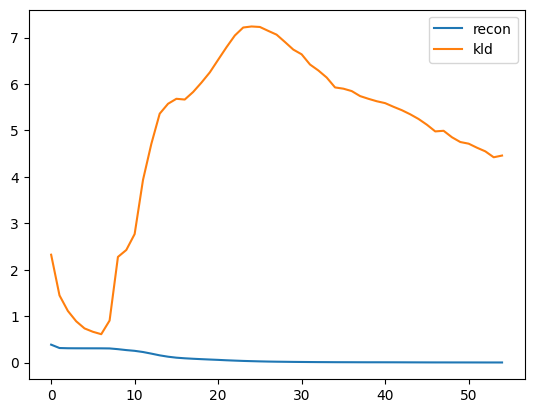

In [17]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
model = train_cvae(pkl_path='mazes.pkl', n_samples=2000, batch_size=64, epochs=55, lr=1e-3, latent_dim=64, device=device)

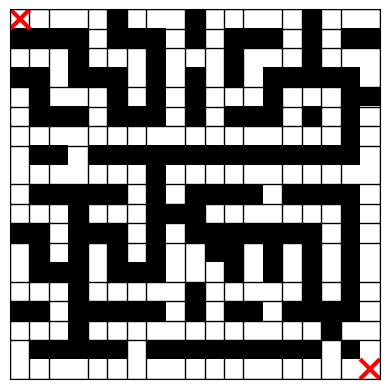

-1


In [18]:
sample = model.generate(67.0, n=1, device=device)
sample = sample[0][:, :19]      # remove last row
sample = sample[:19, :]      # remove last column
visualize_maze(sample, text=False)
print(maze_path_length(sample))

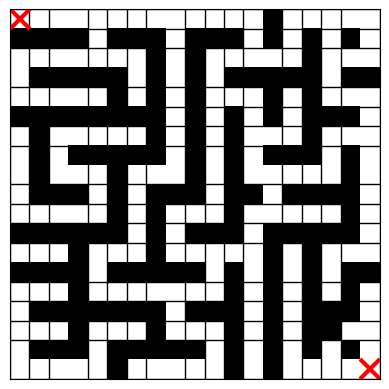

-1


In [19]:
sample = model.generate(100.0, n=1, device=device)
sample = sample[0][:, :19]      # remove last row
sample = sample[:19, :]      # remove last column
visualize_maze(sample, text=False)
print(maze_path_length(sample))

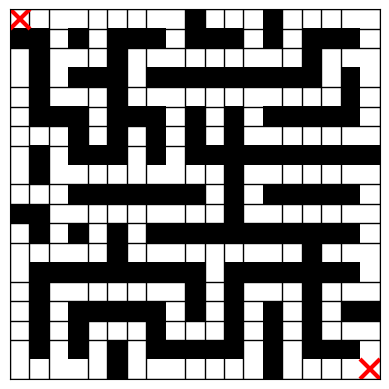

68


In [20]:
sample = model.generate(40, n=1, device=device)
sample = sample[0][:, :19]      # remove last row
sample = sample[:19, :]      # remove last column
visualize_maze(sample, text=False)
print(maze_path_length(sample))

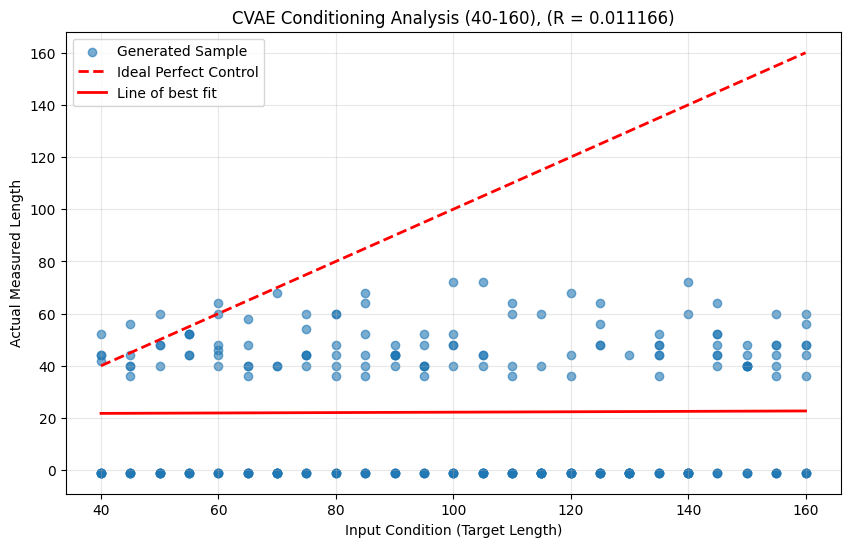

In [25]:
model.eval()
input_vals = []
measured_vals = []

for tgt in range(40, 161, 5):
    mazes = model.generate(float(tgt), n=10, device=device)
    
    for i in range(10):
        m = mazes[i]
        # crop
        m = m[:19, :19]
        actual = maze_path_length(m)
        input_vals.append(tgt)
        measured_vals.append(actual)

plt.figure(figsize=(10, 6))
plt.scatter(input_vals, measured_vals, alpha=0.6, label='Generated Sample')
plt.plot([40, 160], [40, 160], 'r--', lw=2, label='Ideal Perfect Control')
x = np.array(input_vals)
y = np.array(measured_vals)
r_value = np.corrcoef(x, y)[0, 1]
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), color='red', lw=2, label='Line of best fit')
plt.xlabel("Input Condition (Target Length)")
plt.ylabel("Actual Measured Length")
plt.title(f"CVAE Conditioning Analysis (40-160), (R = {r_value:3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()